# AGGLOMERATIVE HIERARCHICAL CLUSTERING #

* DATA


In [50]:
# import pandas as pd
# import matplotlib.pyplot as plt

# from scipy.cluster.hierarchy import linkage, dendrogram
# from sklearn.cluster import AgglomerativeClustering
# from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)

In [51]:
import pandas as pd

# ==============================================================================
# DATA
# ==============================================================================
df_ahc = pd.read_csv('dataset_final_skripsi_normalisasi.csv')
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota',
]

df_ahc[kolom_string] = df_ahc[kolom_string].astype(str)

kolom_numerik = [
    col for col in df_ahc.select_dtypes(include='number').columns
    if col != 'tahun'
]

print("=========== DATA ===========")
df_ahc

=========== DATA ===========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073


* CLUSTERING

In [52]:
from scipy.cluster.hierarchy import linkage

# ==============================================================================
# 1. HITUNG MATRIKS JARAK/LINKAGE
# ==============================================================================

linkage_matrix = linkage(
    df_ahc[kolom_numerik],
    method="ward",
    metric="euclidean"
)

print("========== HASIL LINKAGE MATRIX ==========")
linkage_matrix.round(4)

========== HASIL LINKAGE MATRIX ==========


array([[5.60000e+01, 9.40000e+01, 1.11200e-01, 2.00000e+00],
       [3.70000e+01, 7.50000e+01, 1.28100e-01, 2.00000e+00],
       [2.22000e+02, 2.60000e+02, 1.34000e-01, 2.00000e+00],
       ...,
       [4.63000e+02, 5.25000e+02, 3.22370e+01, 2.30000e+01],
       [5.27000e+02, 5.28000e+02, 4.51747e+01, 2.64000e+02],
       [5.23000e+02, 5.29000e+02, 6.79735e+01, 2.66000e+02]])

In [53]:
# ==============================================================================
# 2. PASANGAN CLUSTER TERDEKAT
# ==============================================================================

linkage_df = pd.DataFrame(
    linkage_matrix,
    columns=[
        "Cluster 1",
        "Cluster 2",
        "Jarak",
        "Jumlah Anggota"
    ]
)

print("========== PASANGAN CLUSTER TERDEKAT ==========")
linkage_df.round(4)

========== PASANGAN CLUSTER TERDEKAT ==========


,Cluster 1,Cluster 2,Jarak,Jumlah Anggota
0,56.0,94.0,0.1112,2.0
1,37.0,75.0,0.1281,2.0
2,222.0,260.0,0.1340,2.0
3,33.0,71.0,0.1459,2.0
4,73.0,111.0,0.1499,2.0
...,...,...,...,...
260,515.0,520.0,18.2333,81.0
261,524.0,526.0,22.5920,241.0
262,463.0,525.0,32.2370,23.0
263,527.0,528.0,45.1747,264.0


========== DENDROGRAM ==========


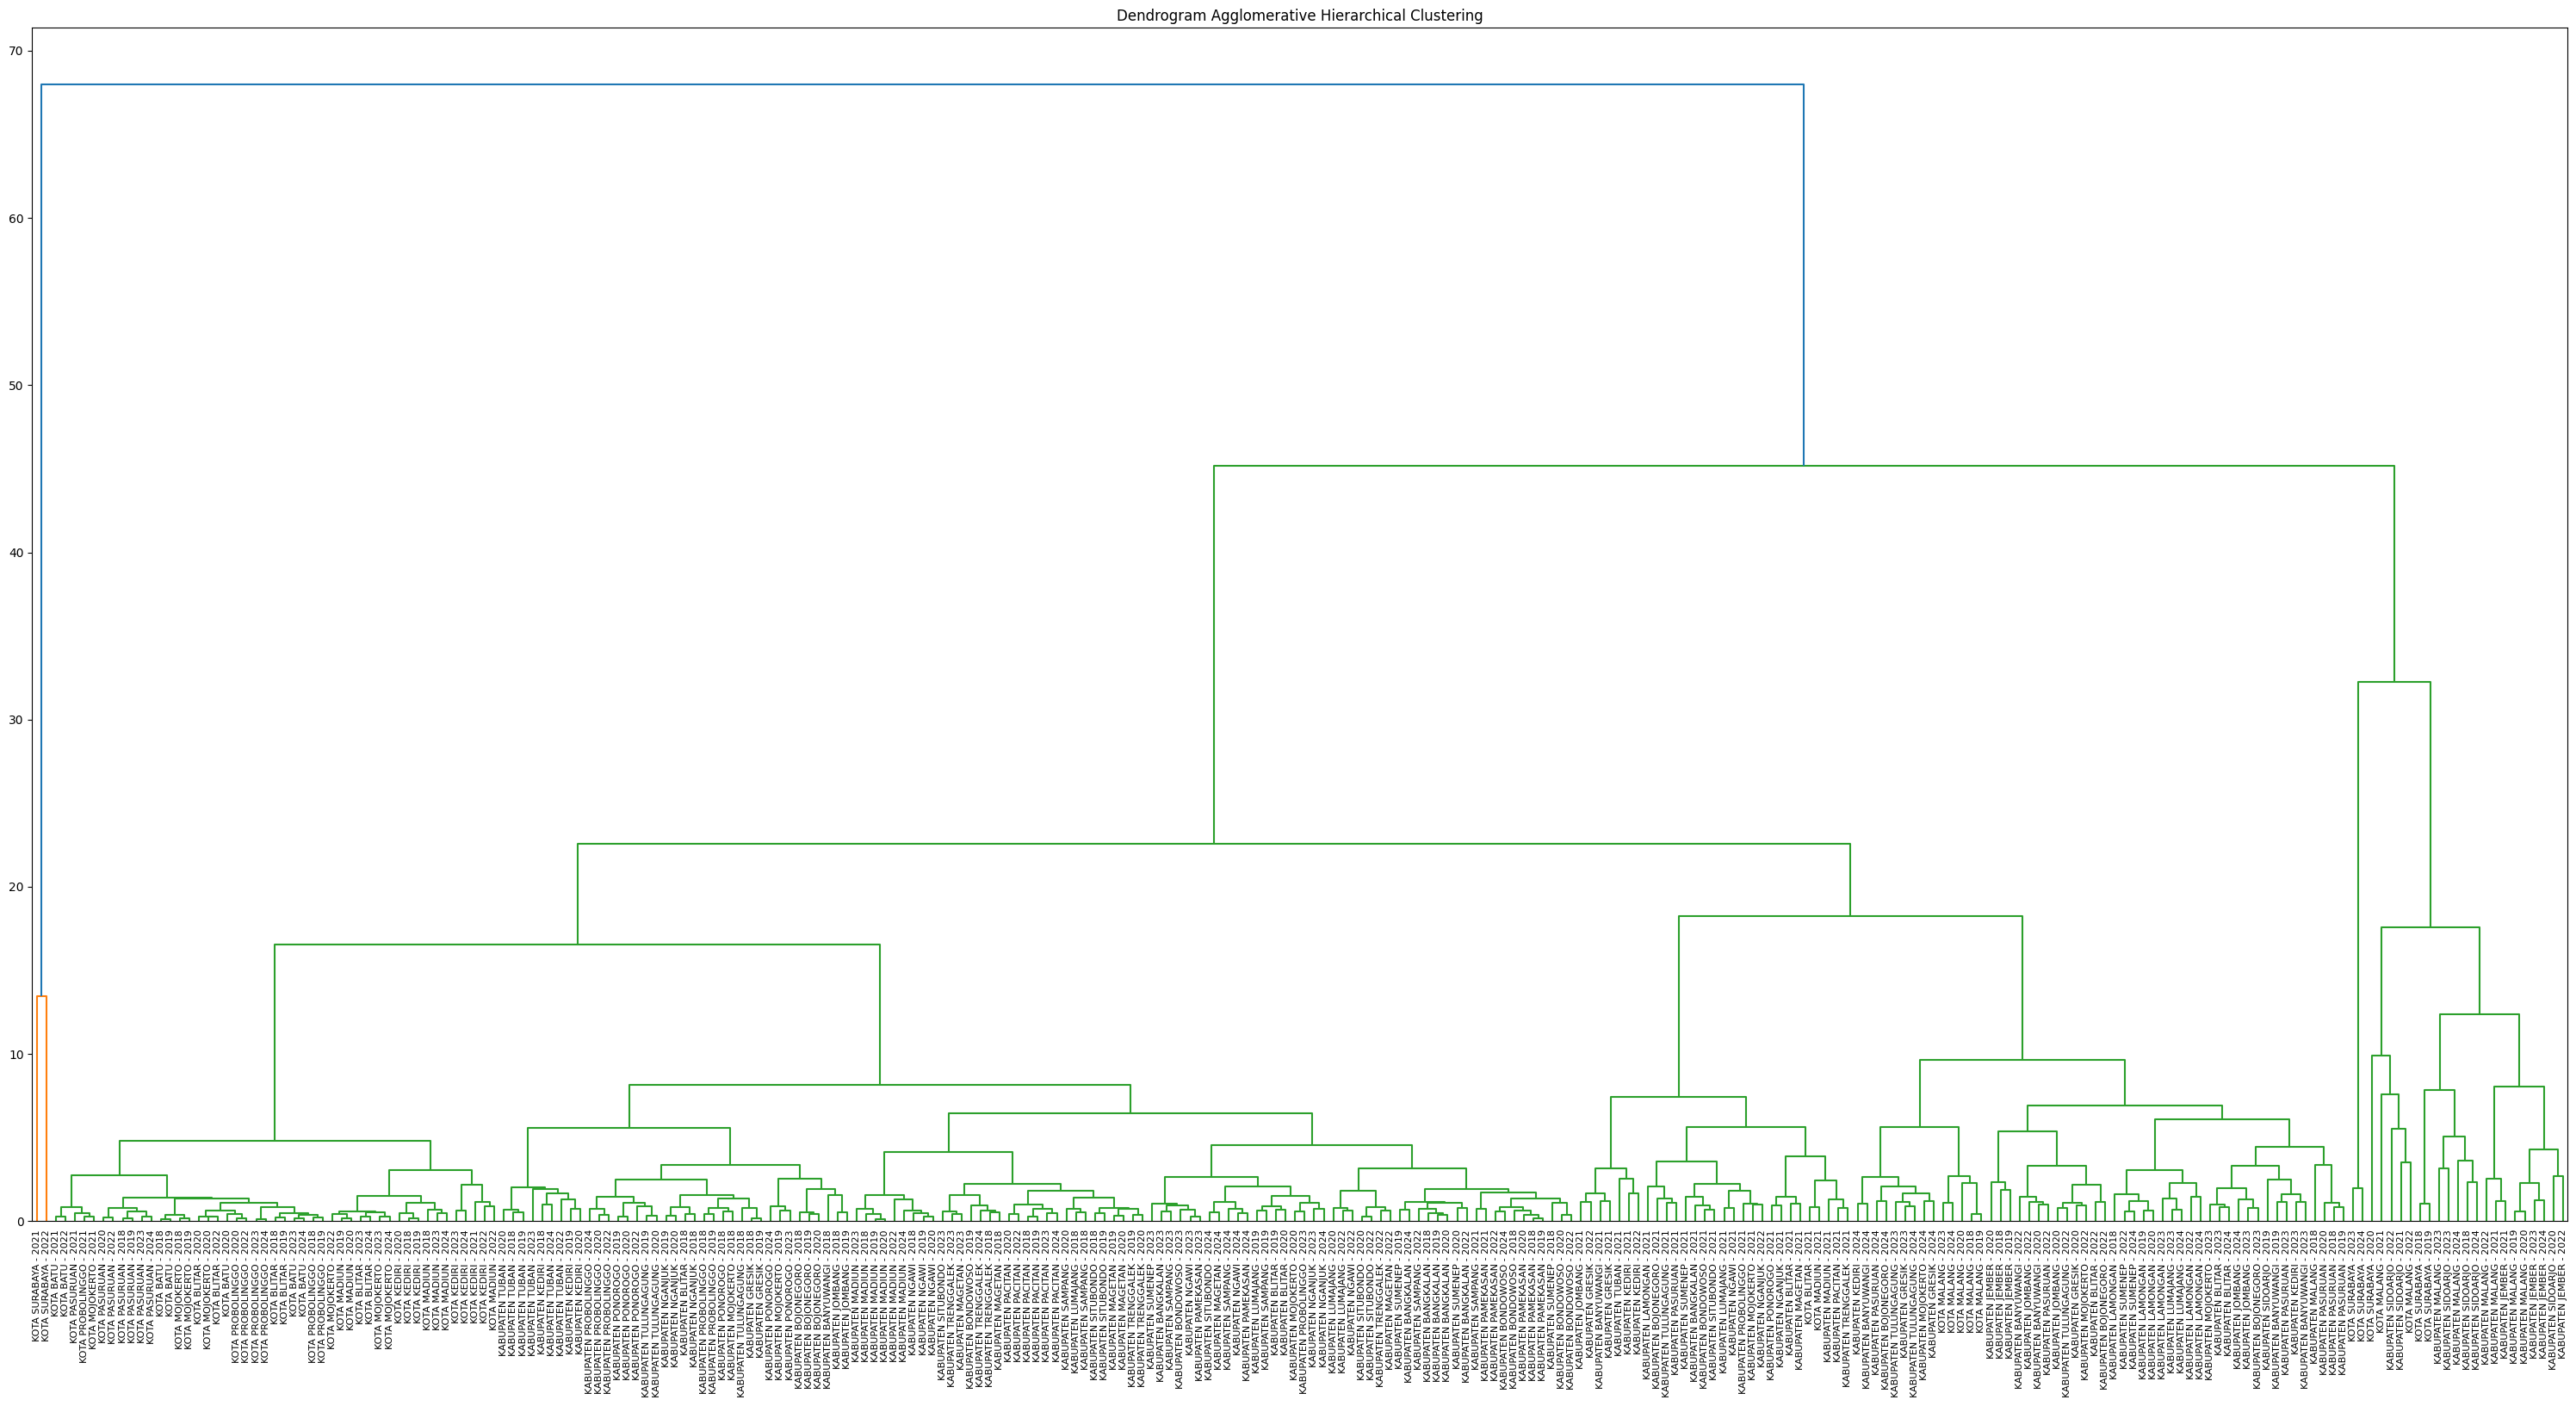

In [54]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# --------------------------
# 2.1. DENDROGRAM
# --------------------------

print("========== DENDROGRAM ==========")

plt.figure(figsize=(38,18))

dendrogram(
    linkage_matrix,
    # color_threshold=8,
    labels = (
    df_ahc["nama_kabupaten_kota"].astype(str)
    + " - "
    + df_ahc["tahun"].astype(str)
).values,
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True,
)

plt.title("Dendrogram Agglomerative Hierarchical Clustering")

plt.show()

In [55]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

#===============================================================================
# 3. EVALUASI CLUSTER
#===============================================================================

hasil_evaluasi = []

for k in range(2,11):

    ahc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        metric="euclidean"
    )

    cluster = ahc.fit_predict(df_ahc[kolom_numerik])
    
    silhouette = silhouette_score(df_ahc[kolom_numerik], cluster)
    dbi = davies_bouldin_score(df_ahc[kolom_numerik], cluster)
    chi = calinski_harabasz_score(df_ahc[kolom_numerik], cluster)
    
    hasil_evaluasi.append({
    'Jumlah Cluster': k,
    'Silhouette Score': silhouette,
    'Davies-Bouldin Index': dbi,
    'Calinski-Harabasz Index': chi
    })
    
hasil_evaluasi = pd.DataFrame(hasil_evaluasi)
    
print("========== HASIL EVALUASI JUMLAH CLUSTER==========")
display(hasil_evaluasi.round(4))

========== HASIL EVALUASI JUMLAH CLUSTER==========


,Jumlah Cluster,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.8887,0.2718,196.4649
1,3,0.6178,0.8570,210.1633
2,4,0.5808,0.7051,214.9464
3,5,0.2790,1.0932,204.6200
4,6,0.2984,0.9904,194.3485
5,7,0.3096,1.0269,193.1761
6,8,0.2820,1.0383,197.4566
7,9,0.2787,0.9114,196.4418
8,10,0.2875,0.9001,196.6442


In [56]:
# --------------------------
# 3.1. JUMLAH CLUSTER OPTIMAL
# --------------------------

print("========== JUMLAH CLUSTER OPTIMAL ==========")

jumlah_cluster = hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'Jumlah Cluster']
print("1. Jumlah Cluster Optimal berdasarkan Silhouette Score:", jumlah_cluster)

jumlah_cluster = hasil_evaluasi.loc[hasil_evaluasi['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster']
print("2. Jumlah Cluster Optimal berdasarkan Davies-Bouldin Index:", jumlah_cluster)

jumlah_cluster = hasil_evaluasi.loc[hasil_evaluasi['Calinski-Harabasz Index'].idxmax(), 'Jumlah Cluster']
print("3. Jumlah Cluster Optimal berdasarkan Calinski-Harabasz Index:", jumlah_cluster)


========== JUMLAH CLUSTER OPTIMAL ==========
1. Jumlah Cluster Optimal berdasarkan Silhouette Score: 2
2. Jumlah Cluster Optimal berdasarkan Davies-Bouldin Index: 2
3. Jumlah Cluster Optimal berdasarkan Calinski-Harabasz Index: 4


_Pemotongan klaster yang diggunakan_

In [57]:
k = 2

In [58]:
from sklearn.cluster import AgglomerativeClustering

#===============================================================================
# 4. PROSES CLUSTERING 
#===============================================================================

print("========== PROSES AGGLOMERATIVE HIERARCHICAL CLUSTERING ==========")

# --------------------------
# 4.1. INISIALISASI MODEL & PARAMETER AGGLOMERATIVE HIERARCHICAL CLUSTERING
# --------------------------
ahc = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward",
    metric="euclidean"
)

# --------------------------
# 4.2. FIT MODEL AGGLOMERATIVE HIERARCHICAL CLUSTERING
# --------------------------
ahc.fit(df_ahc[kolom_numerik])

# --------------------------
# 4.3. SIMPAN LABEL CLUSTER
# --------------------------
df_ahc["cluster"] = ahc.labels_ + 1

print("========== HASIL CLUSTERING AGGLOMERATIVE HIERARCHICAL ==========")
df_ahc

========== PROSES AGGLOMERATIVE HIERARCHICAL CLUSTERING ==========
========== HASIL CLUSTERING AGGLOMERATIVE HIERARCHICAL ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073,1


In [59]:
# --------------------------
# 4.4. JUMLAH ANGGOTA CLUSTER
# --------------------------
jumlah_cluster = (
    df_ahc["cluster"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

cluster
1    264
2      2
Name: count, dtype: int64

* EVALUASI

In [60]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ===============================================================================
# 5. EVALUASI
# ===============================================================================

silhouette = silhouette_score(
    df_ahc[kolom_numerik],
    df_ahc['cluster']
)

dbi = davies_bouldin_score(
    df_ahc[kolom_numerik],
    df_ahc['cluster']
)

chi = calinski_harabasz_score(
    df_ahc[kolom_numerik],
    df_ahc['cluster']
)

print("========== HASIL EVALUASI AGGLOMERATIVE HIERARCHICAL CLUSTERING ==========")
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.4f}")

========== HASIL EVALUASI AGGLOMERATIVE HIERARCHICAL CLUSTERING ==========
Silhouette Score        : 0.8887
Davies-Bouldin Index    : 0.2718
Calinski-Harabasz Index : 196.4649


# _SUB CLUSTER_

In [61]:
# ===============================================================================
# 1. CLUSTER UTAMA
# ===============================================================================

# sub-cluster hanya untuk cluster utama cluster 1
df_ahc_sub = df_ahc.loc[
    df_ahc['cluster'] == 1
].copy()

print("Jumlah data Cluster Utama 1 :", len(df_ahc_sub))

Jumlah data Cluster Utama 1 : 264


* CLUSTERING

In [62]:
from scipy.cluster.hierarchy import linkage

# ==============================================================================
# 2. HITUNG MATRIKS JARAK/LINKAGE
# ==============================================================================

linkage_matrix = linkage(
    df_ahc_sub[kolom_numerik],
    method="ward",
    metric="euclidean"
)

print("========== HASIL LINKAGE MATRIX ==========")
linkage_matrix.round(4)

========== HASIL LINKAGE MATRIX ==========


array([[5.60000e+01, 9.40000e+01, 1.11200e-01, 2.00000e+00],
       [3.70000e+01, 7.50000e+01, 1.28100e-01, 2.00000e+00],
       [2.20000e+02, 2.58000e+02, 1.34000e-01, 2.00000e+00],
       ...,
       [5.21000e+02, 5.23000e+02, 2.25920e+01, 2.41000e+02],
       [4.61000e+02, 5.22000e+02, 3.22370e+01, 2.30000e+01],
       [5.24000e+02, 5.25000e+02, 4.51747e+01, 2.64000e+02]])

========== DENDROGRAM SUB-CLUSTER ==========


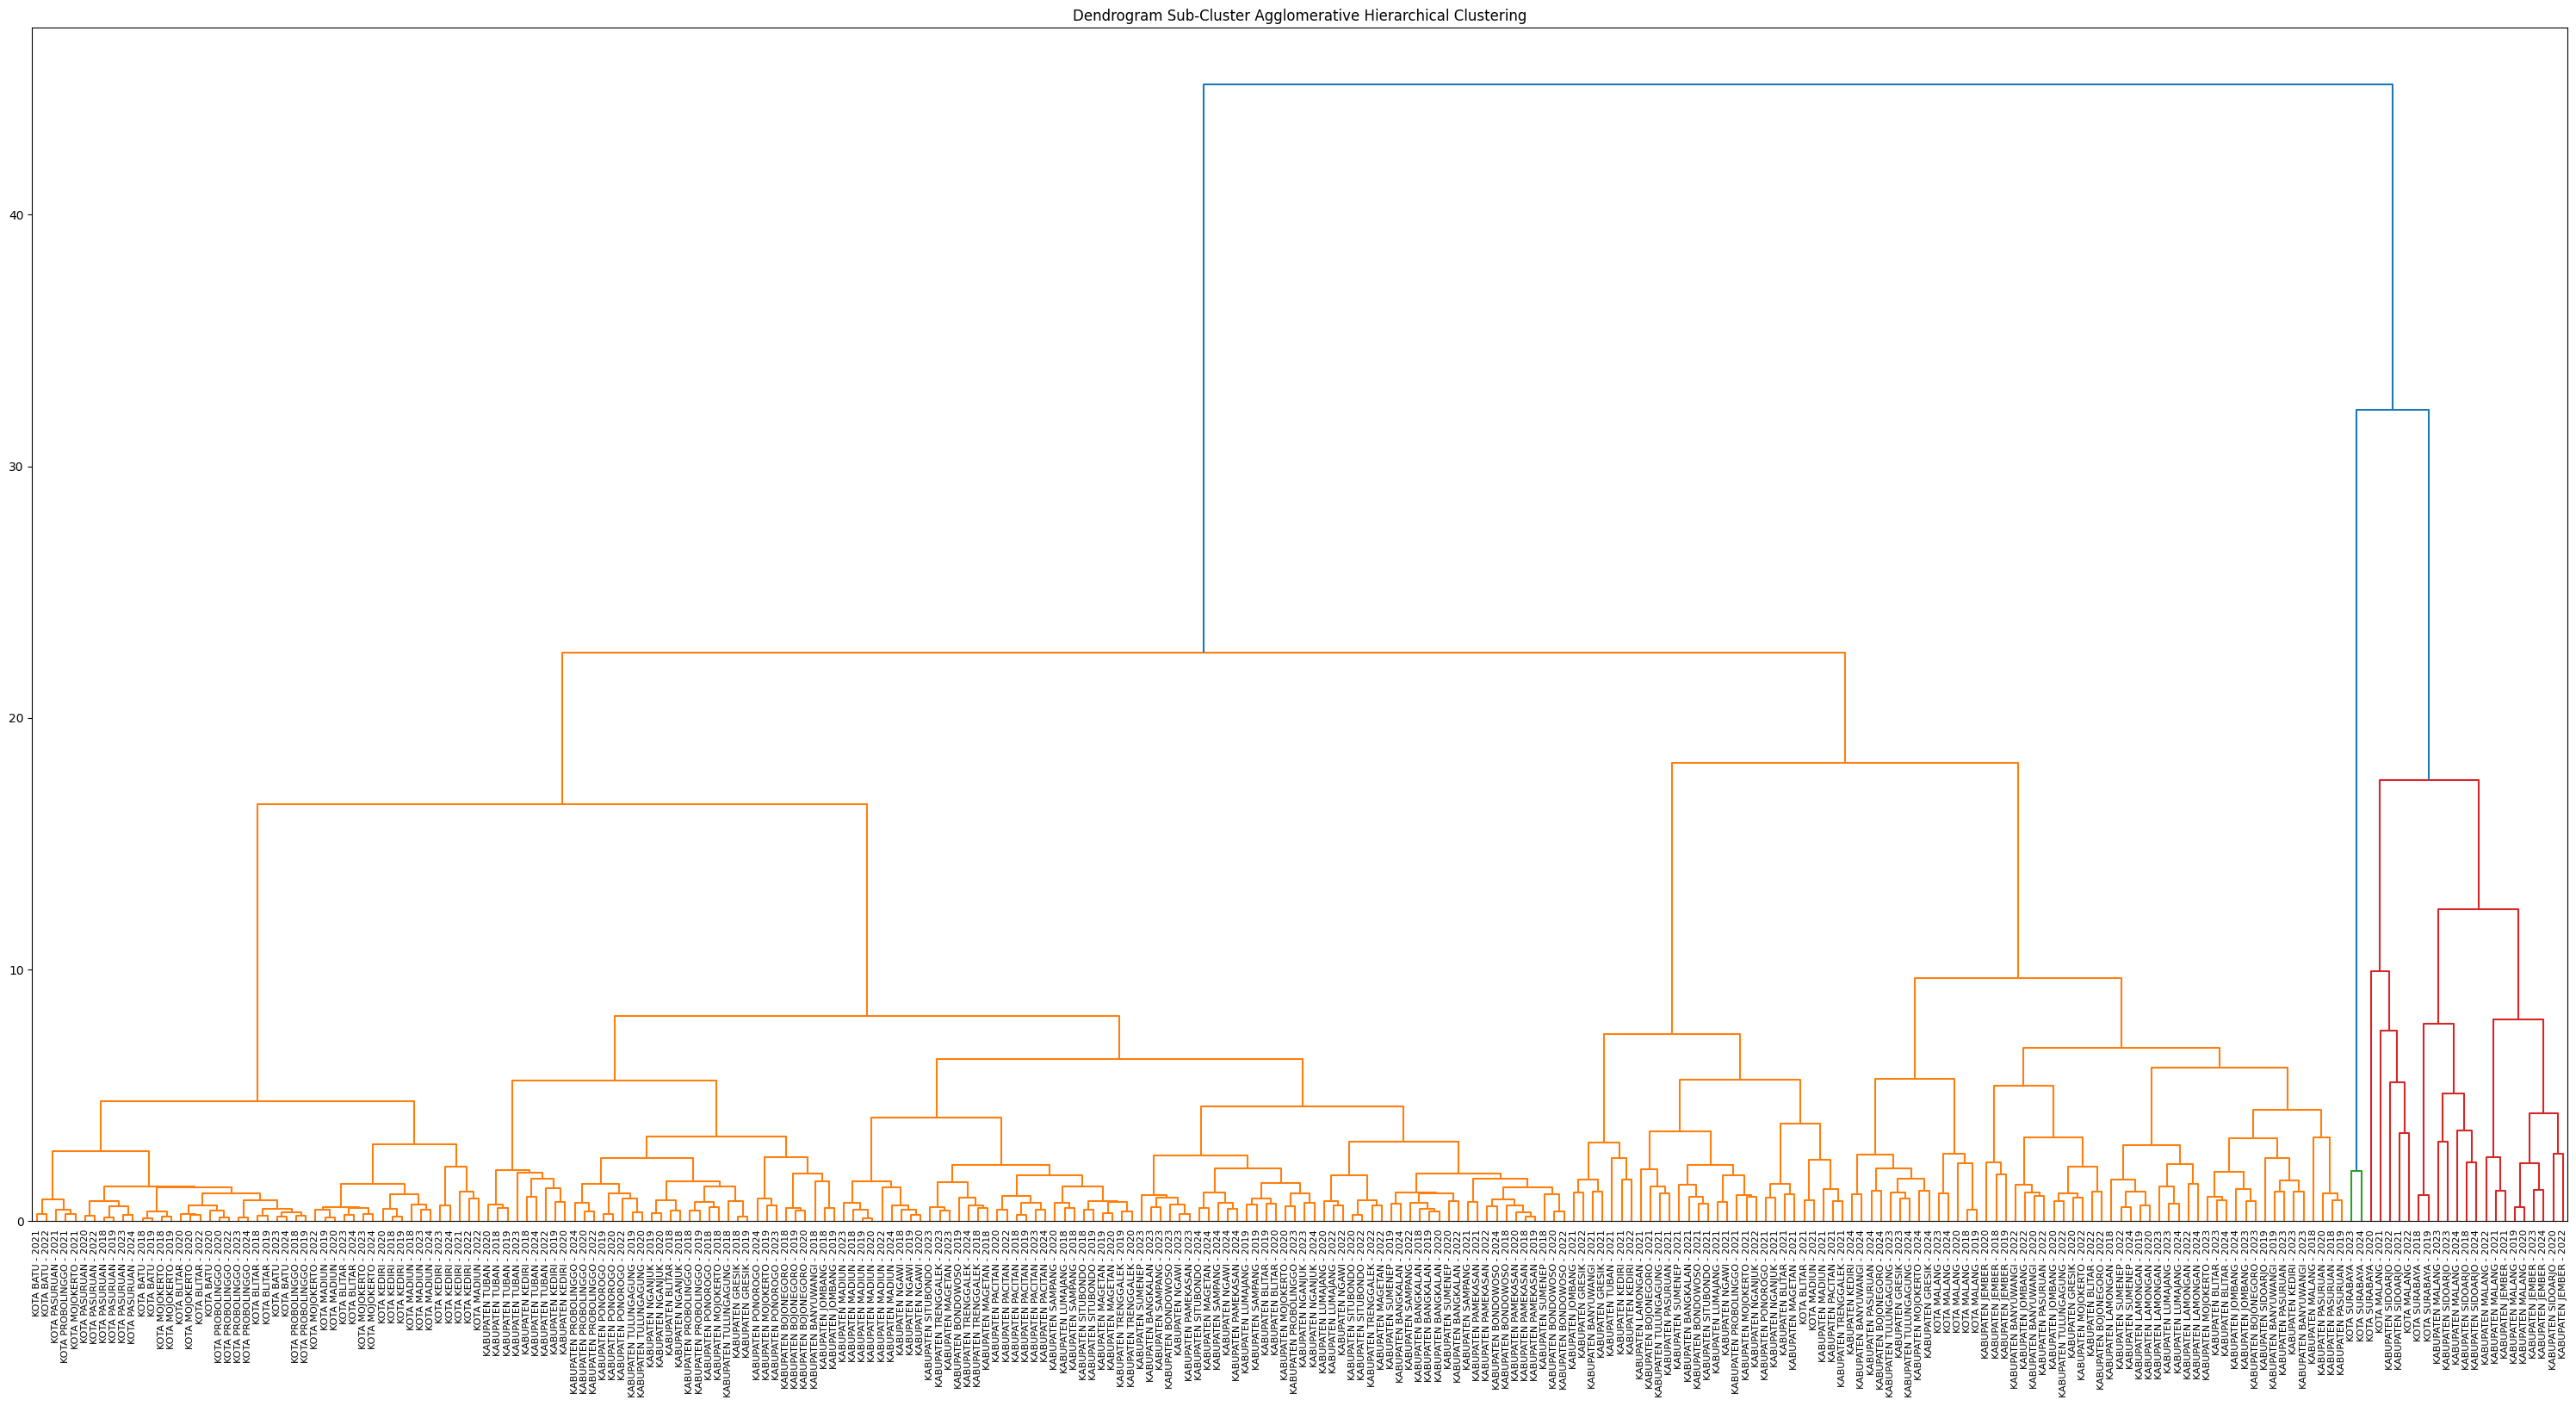

In [63]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# --------------------------
# 2.1. DENDROGRAM
# --------------------------

print("========== DENDROGRAM SUB-CLUSTER ==========")

plt.figure(figsize=(38,18))

dendrogram(
    linkage_matrix,
    # color_threshold=8,
    labels = (
    df_ahc_sub["nama_kabupaten_kota"].astype(str)
    + " - "
    + df_ahc_sub["tahun"].astype(str)
).values,
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True,
)

#plt.axhline(y=8, color="r", linestyle="--", linewidth=1)
plt.title("Dendrogram Sub-Cluster Agglomerative Hierarchical Clustering")

plt.show()

In [64]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ===============================================================================
# 3. EVALUASI JUMLAH SUB-CLUSTER 
# ===============================================================================
max_k_cluster = min(10, len(df_ahc_sub) - 1)


evaluasi_subcluster = []

for k in range(2, max_k_cluster + 1):

    ahc_sub = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward',
        metric='euclidean'
    )

    labels_sub = ahc_sub.fit_predict(df_ahc_sub[kolom_numerik])

    silhouette = silhouette_score(df_ahc_sub[kolom_numerik], labels_sub)
    dbi = davies_bouldin_score(df_ahc_sub[kolom_numerik], labels_sub)
    chi = calinski_harabasz_score(df_ahc_sub[kolom_numerik], labels_sub)

    evaluasi_subcluster.append({
        'Cluster Utama': 1,
        'Jumlah Sub Cluster': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': dbi,
        'Calinski-Harabasz Index': chi
    })

print("\n=== HASIL EVALUASI SUB-CLUSTER ===")

df_evaluasi_subcluster = pd.DataFrame(evaluasi_subcluster)

df_evaluasi_subcluster = df_evaluasi_subcluster.sort_values(
    ['Cluster Utama', 'Jumlah Sub Cluster']
).reset_index(drop=True)

df_evaluasi_subcluster.round(4)


=== HASIL EVALUASI SUB-CLUSTER ===


,Cluster Utama,Jumlah Sub Cluster,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,1,2,0.6183,1.0735,134.1209
1,1,3,0.5819,0.8164,136.3741
2,1,4,0.2778,1.2737,127.6887
3,1,5,0.2973,1.1142,120.6977
4,1,6,0.3086,1.1268,121.5195
5,1,7,0.2809,1.1256,126.7891
6,1,8,0.2896,1.0847,124.5041
7,1,9,0.2905,0.9873,119.3998
8,1,10,0.2890,1.0315,116.3294


In [65]:
# --------------------------
# 3.1. JUMLAH SUB-CLUSTER OPTIMAL
# --------------------------

print("========== JUMLAH SUB-CLUSTER OPTIMAL ==========")

jumlah_cluster = df_evaluasi_subcluster.loc[df_evaluasi_subcluster['Silhouette Score'].idxmax(), 'Jumlah Sub Cluster']
print("1. Jumlah Sub-Cluster Optimal berdasarkan Silhouette Score:", jumlah_cluster)

jumlah_cluster = df_evaluasi_subcluster.loc[df_evaluasi_subcluster['Davies-Bouldin Index'].idxmin(), 'Jumlah Sub Cluster']
print("2. Jumlah Sub-Cluster Optimal berdasarkan Davies-Bouldin Index:", jumlah_cluster)

jumlah_cluster = df_evaluasi_subcluster.loc[df_evaluasi_subcluster['Calinski-Harabasz Index'].idxmax(), 'Jumlah Sub Cluster']
print("3. Jumlah Sub-Cluster Optimal berdasarkan Calinski-Harabasz Index:", jumlah_cluster)


========== JUMLAH SUB-CLUSTER OPTIMAL ==========
1. Jumlah Sub-Cluster Optimal berdasarkan Silhouette Score: 2
2. Jumlah Sub-Cluster Optimal berdasarkan Davies-Bouldin Index: 3
3. Jumlah Sub-Cluster Optimal berdasarkan Calinski-Harabasz Index: 3


In [66]:
from sklearn.cluster import AgglomerativeClustering

# ==============================================================================
# 4. CLUSTERING SUB-CLUSTER
# ==============================================================================

print("========== PROSES AGGLOMERATIVE HIERARCHICAL SUB-CLUSTERING ==========")

# --------------------------
# 4.1. INISIALISASI MODEL & PARAMETER AGGLOMERATIVE HIERARCHICAL CLUSTERING
# --------------------------
k_sub = 3
ahc_sub = AgglomerativeClustering(
    n_clusters=k_sub,
    metric='euclidean',
    linkage='ward'
)

# --------------------------
# 4.2. FIT MODEL AGGLOMERATIVE HIERARCHICAL CLUSTERING
# --------------------------
ahc_sub.fit(df_ahc_sub[kolom_numerik])

# --------------------------
# 4.3. SIMPAN LABEL SUB-CLUSTER
# --------------------------
df_ahc_sub["sub_cluster"] = ahc_sub.labels_ + 1

print("========== HASIL SUB-CLUSTERING AGGLOMERATIVE HIERARCHICAL ==========")
df_ahc_sub

========== PROSES AGGLOMERATIVE HIERARCHICAL SUB-CLUSTERING ==========
========== HASIL SUB-CLUSTERING AGGLOMERATIVE HIERARCHICAL ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster,sub_cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177,1,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178,1,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418,1,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479,1,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734,1,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573,1,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436,1,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073,1,3


In [67]:
# ---------------------------
# 4.4. JUMLAH ANGGOTA SUB-CLUSTER
# ---------------------------

print("========== JUMLAH ANGGOTA SUB-CLUSTER ==========")

jumlah_cluster = (
    df_ahc_sub["sub_cluster"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

========== JUMLAH ANGGOTA SUB-CLUSTER ==========


sub_cluster
1    241
2     21
3      2
Name: count, dtype: int64

* EVALUASI

In [68]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ==============================================================================
# 5. EVALUASI HASIL SUB-CLUSTERING AGGLOMERATIVE HIERARCHICAL
# ==============================================================================

silhouette = silhouette_score(
    df_ahc_sub[kolom_numerik],
    df_ahc_sub['sub_cluster']
)

dbi = davies_bouldin_score(
    df_ahc_sub[kolom_numerik],
    df_ahc_sub['sub_cluster']
)

chi = calinski_harabasz_score(
    df_ahc_sub[kolom_numerik],
    df_ahc_sub['sub_cluster']
)

print("========== HASIL EVALUASI SUB-CLUSTER AGGLOMERATIVE HIERARCHICAL ==========")
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.4f}")

========== HASIL EVALUASI SUB-CLUSTER AGGLOMERATIVE HIERARCHICAL ==========
Silhouette Score        : 0.5819
Davies-Bouldin Index    : 0.8164
Calinski-Harabasz Index : 136.3741


# _SIMPAN DATA_

In [69]:
# ==============================================================================
# SIMPAN HASIL CLUSTERING AGGLOMERATIVE HIERARCHICAL
# ==============================================================================

df_hasil_ahc_norm = df_ahc.copy()

df_hasil_ahc_norm["cluster"] = ahc.labels_ + 1
df_hasil_ahc_norm["sub_cluster"] = 0

df_hasil_ahc_sub = df_hasil_ahc_norm[
    df_hasil_ahc_norm["cluster"] == 1
].index
df_hasil_ahc_norm.loc[
    df_hasil_ahc_sub,
    "sub_cluster"
] = ahc_sub.labels_ + 1

print("========== SIMPAN HASIL CLUSTERING AGGLOMERATIVE HIERARCHICAL ==========")
display(df_hasil_ahc_norm)

========== SIMPAN HASIL CLUSTERING AGGLOMERATIVE HIERARCHICAL ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster,sub_cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177,1,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178,1,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418,1,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479,1,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734,1,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573,1,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436,1,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073,1,3


In [70]:
#===============================================================================
# SIMPAN DATA
#===============================================================================
df_hasil_ahc_norm.to_csv('data_clustering_agglomerative_normalized.csv', index=False)

In [71]:
import pandas as pd

# ==============================================================================
# SIMPAN HASIL CLUSTERING AGGLOMERATIVE HIERARCHICAL (DATA ASLI)
# ==============================================================================

df_hasil_ahc = pd.read_csv('dataset_final_skripsi.csv').copy()

df_hasil_ahc["cluster"] = ahc.labels_ + 1
df_hasil_ahc["sub_cluster"] = 0

df_hasil_ahc_sub = df_hasil_ahc[
    df_hasil_ahc["cluster"] == 1
].index
df_hasil_ahc.loc[
    df_hasil_ahc_sub,
    "sub_cluster"
] = ahc_sub.labels_ + 1

print("========== SIMPAN HASIL CLUSTERING AGGLOMERATIVE HIERARCHICAL (DATA ASLI) ==========")
display(df_hasil_ahc)

========== SIMPAN HASIL CLUSTERING AGGLOMERATIVE HIERARCHICAL (DATA ASLI) ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster,sub_cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,554394,1,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,870705,1,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,694902,1,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1035290,1,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1157500,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,285,184,571,18844,287,219392,1,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,251,203,963,16010,129,137393,1,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,359,310,1452,23764,756,201767,1,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,2073,3852,11676,851331,2299,2921996,1,3


In [72]:
#===============================================================================
# SIMPAN DATA
#===============================================================================
df_hasil_ahc.to_csv('data_clustering_agglomerative.csv', index=False)

# _KARAKTERISTIK CLUSTER_

========== KARAKTERISTIK CLUSTER UTAMA ==========


,Jumlah Anggota,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster,,,,,,,,,
1,264,9.2803,15.9432,729.1023,313.3371,1539.6553,140071.7311,2606.5227,1.045794e+06
2,2,41.0000,22.0000,2009.0000,4742.0000,10556.0000,343275.5000,64354.5000,2.923300e+06


========== KARAKTERISTIK CLUSTER UTAMA 1 | SUB-CLUSTER ==========


,Jumlah Anggota,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
sub_cluster,,,,,,,,,
1,241,8.7261,14.9710,666.5394,237.0207,1252.0954,120690.3568,2104.2905,9.132142e+05
2,21,12.6667,26.4762,1297.3333,861.4286,3907.3333,293610.4286,8238.7619,2.387918e+06
3,2,40.5000,22.5000,2301.5000,3754.5000,11330.0000,863371.0000,3987.0000,2.929414e+06


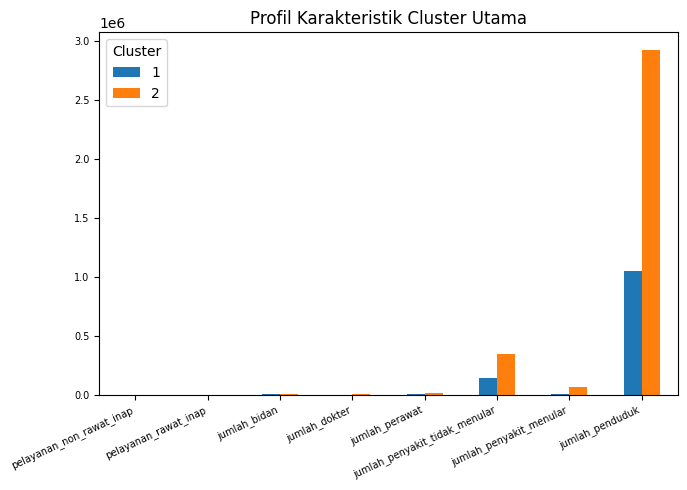

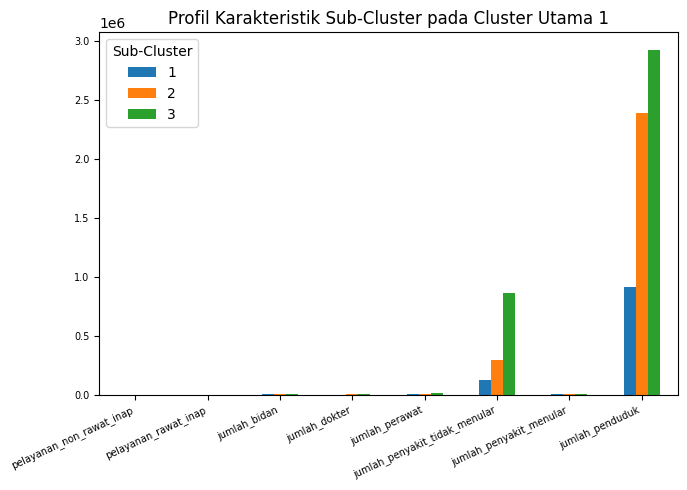

In [73]:
# ==========================================================
# PROFIL / KARAKTERISTIK CLUSTER
# ==========================================================

df_profil = df_hasil_ahc.copy()

# ----------------------------------------------------------
# 1. PROFIL CLUSTER UTAMA
# ----------------------------------------------------------

profil_cluster = (
    df_profil
    .groupby('cluster')[kolom_numerik]
    .mean()
)

jumlah_cluster = (
    df_profil['cluster']
    .value_counts()
    .sort_index()
)

profil_cluster_lengkap = profil_cluster.copy()

profil_cluster_lengkap.insert(
    0, 'Jumlah Anggota', jumlah_cluster
)

print("========== KARAKTERISTIK CLUSTER UTAMA ==========")
display(profil_cluster_lengkap.round(4))


# ----------------------------------------------------------
# 2. PROFIL SUB-CLUSTER CLUSTER UTAMA 1
# ----------------------------------------------------------

df_cluster1 = df_profil[
    df_profil['cluster'] == 1
].copy()

profil_subcluster = (
    df_cluster1
    .groupby('sub_cluster')[kolom_numerik]
    .mean()
)

jumlah_subcluster = (
    df_cluster1['sub_cluster']
    .value_counts()
    .sort_index()
)

profil_subcluster_lengkap = profil_subcluster.copy()

profil_subcluster_lengkap.insert(0, 'Jumlah Anggota', jumlah_subcluster)

print("========== KARAKTERISTIK CLUSTER UTAMA 1 | SUB-CLUSTER ==========")
display(profil_subcluster_lengkap.round(4))


# ----------------------------------------------------------
# 3. VISUALISASI PROFIL CLUSTER UTAMA
# ----------------------------------------------------------

profil_cluster.T.plot(
    kind='bar',
    figsize=(7, 5),
    fontsize=7
)

plt.title("Profil Karakteristik Cluster Utama")
plt.xticks(rotation=25, ha='right')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 4. VISUALISASI PROFIL SUB-CLUSTER
# ----------------------------------------------------------

profil_subcluster.T.plot(
    kind='bar',
    figsize=(7, 5),
    fontsize=7
)

plt.title("Profil Karakteristik Sub-Cluster pada Cluster Utama 1")
plt.xticks(rotation=25, ha='right')
plt.legend(title="Sub-Cluster")
plt.tight_layout()
plt.show()